In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.offline as pyo
import plotly.io as pio
pio.renderers.default = "notebook_connected"

## Load the Dataset

In [3]:
df = pd.read_csv("../Data/gdp.csv")

## Preview the data structure

In [4]:
df.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


## Shape (rows & columns)

In [5]:
df.shape

(11507, 4)

## Info (data types, nulls)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11507 entries, 0 to 11506
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  11507 non-null  object 
 1   Country Code  11507 non-null  object 
 2   Year          11507 non-null  int64  
 3   Value         11507 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 359.7+ KB


## Summary statistics

In [7]:
df.describe()

,Year,Value
count,11507.000000,1.150700e+04
mean,1991.265230,1.005972e+12
std,15.886648,4.533056e+12
min,1960.000000,8.824448e+06
25%,1978.000000,2.056874e+09
50%,1993.000000,1.436880e+10
75%,2005.000000,1.796394e+11
max,2016.000000,7.904923e+13


### Check missing values

In [8]:
df.isnull().sum()

Country Name    0
Country Code    0
Year            0
Value           0
dtype: int64

## Check description of each column

In [9]:
df.columns

Index(['Country Name', 'Country Code', 'Year', 'Value'], dtype='object')

In [10]:
df['Country Name'].describe()

count                      11507
unique                       256
top       Caribbean small states
freq                          57
Name: Country Name, dtype: object

In [11]:
df['Country Code'].describe()

count     11507
unique      256
top         CSS
freq         57
Name: Country Code, dtype: object

In [12]:
df['Year'].describe()

count    11507.000000
mean      1991.265230
std         15.886648
min       1960.000000
25%       1978.000000
50%       1993.000000
75%       2005.000000
max       2016.000000
Name: Year, dtype: float64

## Analysis of Arab World

<Axes: title={'center': 'GDP Map of Arab World'}, xlabel='Year', ylabel='GDP_Value'>

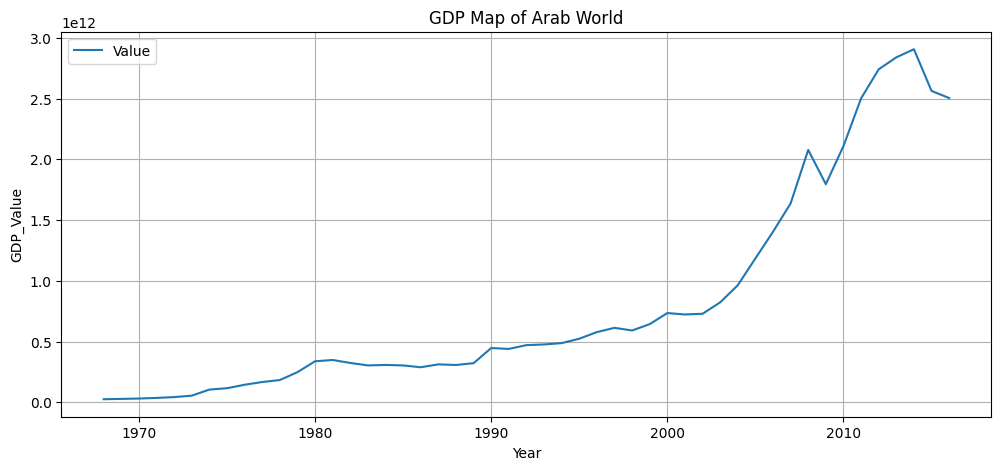

In [13]:
df_pr = df[df['Country Name'] == 'Arab World']
df_pr.plot( kind = 'line', x = 'Year', y = 'Value',
            xlabel = 'Year', ylabel = 'GDP_Value',
            title = 'GDP Map of Arab World',
            legend = True, figsize = (12, 5),
            grid = True)

## GDP Growth in Arab World

In [14]:
data = df_pr.values
gdp_change = [0]
for i in range(1, len(data)):
    curr = data[i][3]
    prev = data[i - 1][3]
    gdp_change.append(round(((curr - prev) / prev) * 100, 2))
df_pr = df_pr.assign(GDP = gdp_change)

## GDP Growth in India

In [15]:
df_pr = df[df['Country Name'] == 'India'].copy()
df_pr['GDP_Growth'] = df_pr['Value'].pct_change() * 100
df_pr['GDP_Growth'] = df_pr['GDP_Growth'].fillna(0)
df_pr

,Country Name,Country Code,Year,Value,GDP_Growth
6074,India,IND,1960,3.653593e+10,0.000000
6075,India,IND,1961,3.870910e+10,5.948039
6076,India,IND,1962,4.159907e+10,7.465879
6077,India,IND,1963,4.777600e+10,14.848723
6078,India,IND,1964,5.572687e+10,16.641979
6079,India,IND,1965,5.876042e+10,5.443606
6080,India,IND,1966,4.525364e+10,-22.986191
6081,India,IND,1967,4.946617e+10,9.308704
6082,India,IND,1968,5.237732e+10,5.885144
6083,India,IND,1969,5.766833e+10,10.101711


## GDP Growth on whole Data Set

In [16]:
final_data = []
for country in df['Country Name'].unique():
    df_pr = df[df['Country Name'] == country]
    data = df_pr.values
    gdp_change = [0]
    for i in range(1, len(data)):
        curr = data[i][3]
        prev = data[i - 1][3]
        gdp_change.append(round(((curr - prev) / prev) * 100, 2))
    df_pr = df_pr.assign(GDP = gdp_change)
    final_data.append(df_pr)

In [17]:
df = pd.concat(final_data, axis = 0)

In [18]:
df

,Country Name,Country Code,Year,Value,GDP
0,Arab World,ARB,1968,2.576068e+10,0.00
1,Arab World,ARB,1969,2.843420e+10,10.38
2,Arab World,ARB,1970,3.138550e+10,10.38
3,Arab World,ARB,1971,3.642691e+10,16.06
4,Arab World,ARB,1972,4.331606e+10,18.91
...,...,...,...,...,...
11502,Zimbabwe,ZWE,2012,1.424249e+10,17.72
11503,Zimbabwe,ZWE,2013,1.545177e+10,8.49
11504,Zimbabwe,ZWE,2014,1.589105e+10,2.84
11505,Zimbabwe,ZWE,2015,1.630467e+10,2.60


In [19]:
df.groupby('Country Name')['GDP'].mean().sort_values(ascending = False)

Country Name
Cayman Islands              108.380000
Equatorial Guinea            22.312453
Nauru                        20.650000
Iraq                         18.075854
Oman                         17.681154
                               ...    
Barbados                      3.109259
San Marino                    2.148333
American Samoa                1.937333
Northern Mariana Islands      0.338667
South Sudan                  -3.166250
Name: GDP, Length: 256, dtype: float64

# Plotting Graphs

### GDP plot for world.

In [20]:
df_pr = df[df['Country Name'] == 'World']
fig = px.line(df_pr, x = 'Year', y = 'Value', title = 'World GDP Analysis')
fig

In [21]:
df_pr = df[df['Country Name'] == 'India']
fig = px.line(df_pr, x = 'Year', y = 'Value', title = 'World GDP Analysis', range_y = [0, 8000000000000])
fig

### Plotting offline graphs

In [22]:
pyo.plot(fig, filename = 'India GDP.html')

'India GDP.html'

# Plotting graphs in bulk

In [24]:
# Create a directory and its path to store individual figure.
os.mkdir('../GDP Individual')
for country in df['Country Name'].unique():
    df_pr = df[df['Country Name'] == country]
    fig = px.line(df_pr, x = 'Year', y = 'Value', title =  country + ' GDP Analysis')
    pyo.plot(fig, filename =  '../GDP Individual/' + country + ' GDP.html', auto_open=False)

In [25]:
# Create a directory and its path to store individual figure.
os.mkdir('../GDP Individual WRT 80T')
for country in df['Country Name'].unique():
    df_pr = df[df['Country Name'] == country]
    fig = px.line(df_pr, x = 'Year', y = 'Value', title =  country + ' GDP Analysis')
    pyo.plot(fig, filename =  '../GDP Individual WRT 80T/' + country + ' GDP.html', auto_open=False)